# parqit, part 2: descriptive statistics without loading the data

Every statistics command in this notebook is computed **by the engine, on the file**:
DuckDB reads the data where they are and only the table of results comes back to Stata.
The statistics commands never touch the dataset in Stata's memory: here it stays
**empty** until Section 10, where we choose to collect small tables of results. The same
commands therefore work on files with hundreds of millions of rows.

* **Stata's syntax, with `parqit` in front:** `parqit summarize`, `parqit tabulate`,
  `parqit tabstat`, `parqit correlate`, ...
* **Stata's definitions:** the standard deviation divides by N − 1, percentiles follow
  the rule of `summarize, detail`, and `tabulate` leaves out missing values unless you
  ask for them.
* **Two differences to remember.** Statistics take explicit variable names and no
  `if`/`in` qualifier (only `count` and `list` accept `if`): to describe a subgroup,
  filter the view, or a second view, first (Section 9). And comparisons with missing
  values follow SQL's rule unless you switch to Stata's (Section 11).

**Before you start:** as in part 1, you need Stata 16 or newer, parqit **0.2.1** or
later and, to run the cells, Jupyter with the *Stata (nbstata)* kernel
(`pip install nbstata`, then `python -m nbstata.install`). The outputs below were
produced with parqit 0.2.1. The notebook is self-contained: it writes its own file.

**The data:** `nlsw88`, the 1988 extract of the U.S. National Longitudinal Survey of
Young Women (2,246 women) that ships with Stata.

## 0. Setup

The first time, install parqit from the project's GitHub releases by removing the
`*` in front of `net install` (`latest` is version 0.2.1 at the time of writing; to
install exactly that version, replace `latest/download` with `download/v0.2.1`).
Restart Stata (here: the kernel) after installing or updating parqit.

`parqit version` must report 0.2.1 or later. The global `NB` names the scratch folder
where every file of this notebook is written, under Stata's temporary directory.

In [1]:
* First time only: install parqit 0.2.1 from GitHub
* net install parqit, from("https://github.com/reisportela/parqit/releases/latest/download") replace
set linesize 100
parqit version
global NB "`c(tmpdir)'/parqit_notebooks"
capture mkdir "$NB"
display as text "Files for this notebook go to: " as result "$NB"

parqit version 0.2.1  (engine: DuckDB v1.5.3, Stata Plugin Interface 3.0, parallelism: DuckDB)
CPUs available: 48; engine threads: 48; fill workers: auto; stream buffer (MB): auto
Files for this notebook go to: /tmp/parqit_notebooks


## 1. Write the file and open a lazy view

The survey is written to Parquet once; then Stata's memory is cleared and a lazy view
opens on the file. From here on, every statistic is computed on disk.

In [2]:
sysuse nlsw88, clear
parqit save "$NB/nlsw88.parquet", replace data compression(zstd)
clear
parqit use using "$NB/nlsw88.parquet"
display as text "Stata's memory: " as result _N as text " observations"

(NLSW, 1988 extract)
(2246 obs, 17 vars written to /tmp/parqit_notebooks/nlsw88.parquet)
(lazy view default opened over /tmp/parqit_notebooks/nlsw88.parquet: 17 columns; schema probed, no r
> ows loaded — use parqit collect or parqit save)
Stata's memory: 0 observations


## 2. Know your variables

`parqit describe` lists the variables of the view with their labels. `parqit codebook`
adds, for each variable, its storage type, its range and the numbers of distinct and
missing values, in a single pass over the file.

In [3]:
parqit describe


  lazy view over /tmp/parqit_notebooks/nlsw88.parquet
  columns: 17   pipeline steps: 0

  variable                         kind     format       label
  ------------------------------------------------------------------------
  idcode                           numeric  %8.0g        NLS ID
  age                              numeric  %8.0g        Age in current year
  race                             numeric  %8.0g        Race
  married                          numeric  %8.0g        Married
  never_married                    numeric  %16.0g       Never married
  grade                            numeric  %8.0g        Current grade completed
  collgrad                         numeric  %16.0g       College graduate
  south                            numeric  %9.0g        Lives in the south
  smsa                             numeric  %9.0g        Lives in SMSA
  c_city                           numeric  %16.0g       Lives in a central city
  industry                         numeric  %23.0g

In [4]:
parqit codebook union wage hours


----------------------------------------------------------------------------------------------------
union                                                                                   Union worker
----------------------------------------------------------------------------------------------------

                  Type: Numeric (byte)

                 Range: [0,1]
         Unique values: 2
               Missing: 368/2,246

----------------------------------------------------------------------------------------------------
wage                                                                                     Hourly wage
----------------------------------------------------------------------------------------------------

                  Type: Numeric (float)

                 Range: [1.004952,40.74659]
         Unique values: 967
               Missing: 0/2,246

----------------------------------------------------------------------------------------------------
hours        

## 3. Missing values and duplicates

Before any analysis: where are the gaps? `parqit misstable summarize` counts the
missing values of each variable, and `parqit misstable patterns` shows which
combinations of gaps occur (1 = observed, 0 = missing).

In [5]:
parqit misstable summarize


    Variable |    Missing    Observed         Obs   % missing
-------------+------------------------------------------------
      idcode |          0       2,246       2,246        0.00
         age |          0       2,246       2,246        0.00
        race |          0       2,246       2,246        0.00
     married |          0       2,246       2,246        0.00
never_marr~d |          0       2,246       2,246        0.00
       grade |          2       2,244       2,246        0.09
    collgrad |          0       2,246       2,246        0.00
       south |          0       2,246       2,246        0.00
        smsa |          0       2,246       2,246        0.00
      c_city |          0       2,246       2,246        0.00
    industry |         14       2,232       2,246        0.62
  occupation |          9       2,237       2,246        0.40
       union |        368       1,878       2,246       16.38
        wage |          0       2,246       2,246        0.00
      

In [6]:
parqit misstable patterns union hours tenure grade industry occupation


   Missing-value patterns
     (1 means complete)

   Frequency   Percent |   Pattern
                       |  1  2  3  4  5  6
  ---------------------+--------------------
        1848     82.28 |  1  1  1  1  1  1
         359     15.98 |  1  1  1  0  1  1
          10      0.45 |  1  1  1  1  1  0
           8      0.36 |  1  0  1  1  1  1
           5      0.22 |  1  1  1  0  1  0
           5      0.22 |  1  0  0  1  1  1
           4      0.18 |  1  1  0  1  1  1
           3      0.13 |  1  1  1  0  0  1
           2      0.09 |  0  1  1  1  1  1
           1      0.04 |  1  1  1  1  0  1
           1      0.04 |  1  0  1  0  1  1
  ---------------------+--------------------
        2246    100.00 |

  Variables are (1) grade (2) industry (3) occupation (4) union (5) hours (6) tenure


`parqit duplicates report` checks that `idcode` identifies each woman once, and
`parqit distinct` counts the distinct values of each variable.

In [7]:
parqit duplicates report idcode
parqit distinct idcode industry occupation


Duplicates in terms of idcode

--------------------------------------
   Copies | Observations       Surplus
----------+---------------------------
        1 |         2246             0
--------------------------------------

    Variable |    Distinct           Obs
-------------+----------------------------
      idcode |       2,246         2,246
    industry |          12         2,246
  occupation |          13         2,246



## 4. Summary statistics

`parqit summarize` without a variable list summarizes every numeric variable.

In [8]:
parqit summarize


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
      idcode |      2,246    2612.654    1480.864          1       5159
         age |      2,246    39.15316    3.060002         34         46
        race |      2,246    1.282725    .4754413          1          3
     married |      2,246    .6420303    .4795099          0          1
never_marr~d |      2,246    .1041852    .3055687          0          1

       grade |      2,244    13.09893    2.521246          0         18
    collgrad |      2,246    .2368655    .4252538          0          1
       south |      2,246    .4194123    .4935728          0          1
        smsa |      2,246    .7039181    .4566292          0          1
      c_city |      2,246    .2916296    .4546139          0          1

    industry |      2,232    8.189516    3.010875          1         12
  occupation |      2,237    4.642825    3.408897          1 

With `detail`: percentiles, the four smallest and largest values, variance, skewness
and kurtosis, laid out as in Stata.

In [9]:
parqit summarize wage, detail


                         Hourly wage
-------------------------------------------------------------
      Percentiles      Smallest
 1%     1.930993       1.004952
 5%     2.801002       1.032247
10%     3.220612       1.151368       Obs               2,246
25%     4.259257       1.344605       Sum of wgt.       2,246

50%      6.27227                      Mean           7.766949
                        Largest       Std. dev.      5.755523
75%     9.597424       40.19808
90%     12.77777       40.19808       Variance       33.12604
95%     16.52979       40.19808       Skewness       3.096199
99%     38.70926       40.74659       Kurtosis       15.85446


As with `summarize`, the results are stored in `r()` and can be used by the next
command:

In [10]:
display as text "Median hourly wage:" _col(22) as result %5.2f r(p50)
display as text "Mean hourly wage:" _col(22) as result %5.2f r(mean)
display as text "Ratio p90/p10:" _col(22) as result %5.2f r(p90)/r(p10)

Median hourly wage:   6.27
Mean hourly wage:     7.77
Ratio p90/p10:        3.97


## 5. Frequency tables

One-way tables show the value labels stored in the file:

In [11]:
parqit tabulate race


       Race |      Freq.     Percent        Cum.
------------+-----------------------------------
      White |      1,637       72.89       72.89
      Black |        583       25.96       98.84
      Other |         26        1.16      100.00
------------+-----------------------------------
      Total |      2,246      100.00


In [12]:
parqit tabulate industry


                Industry |      Freq.     Percent        Cum.
-------------------------+-----------------------------------
   Ag/Forestry/Fisheries |         17        0.76        0.76
                  Mining |          4        0.18        0.94
            Construction |         29        1.30        2.24
           Manufacturing |        367       16.44       18.68
  Transport/Comm/Utility |         90        4.03       22.72
  Wholesale/Retail trade |        333       14.92       37.63
 Finance/Ins/Real estate |        192        8.60       46.24
     Business/Repair svc |         86        3.85       50.09
       Personal services |         97        4.35       54.44
   Entertainment/Rec svc |         17        0.76       55.20
   Professional services |        824       36.92       92.11
   Public administration |        176        7.89      100.00
-------------------------+-----------------------------------
                   Total |      2,232      100.00


As with `tabulate`, missing values are left out; the `missing` option counts them:

In [13]:
parqit tabulate union, missing


 Union worker |      Freq.     Percent        Cum.
--------------+-----------------------------------
     Nonunion |      1,417       63.09       63.09
        Union |        461       20.53       83.62
            . |        368       16.38      100.00
--------------+-----------------------------------
        Total |      2,246      100.00


Two-way tables, here with row and column percentages:

In [14]:
parqit tabulate collgrad union, row col


+-------------------+
| Key               |
|-------------------|
|     frequency     |
|  row percentage   |
| column percentage |
+-------------------+

                 |     Union worker
College graduate |  Nonunion      Union |     Total
-----------------+----------------------+----------
Not college grad |     1,101        313 |     1,414
                 |     77.86      22.14 |    100.00
                 |     77.70      67.90 |     75.29
-----------------+----------------------+----------
    College grad |       316        148 |       464
                 |     68.10      31.90 |    100.00
                 |     22.30      32.10 |     24.71
-----------------+----------------------+----------
           Total |     1,417        461 |     1,878
                 |     75.45      24.55 |    100.00
                 |    100.00     100.00 |    100.00


## 6. Tables of statistics

`parqit tabstat` puts the statistics you choose side by side:

In [15]:
parqit tabstat wage hours ttl_exp tenure, statistics(n mean sd p25 p50 p75)


   Stats |      wage     hours   ttl_exp    tenure
---------+----------------------------------------
       N |      2246      2242      2246      2231
    Mean |  7.766949  37.21811  12.53498   5.97785
      SD |  5.755523  10.50914  4.610208  5.510331
     p25 |  4.259257        35  9.211538  1.583333
     p50 |   6.27227        40    13.125  3.833333
     p75 |  9.597424        40  15.98077  9.333333
--------------------------------------------------


With `by()`, one row per group; as in `tabstat`, the women with a missing occupation
are left out:

In [16]:
parqit tabstat wage, statistics(n mean sd p50) by(occupation)


Summary for variables: wage
Group variable: occupation (Occupation)

      occupation |         N      Mean        SD       p50
-----------------+----------------------------------------
Professional/Te~ |       317  10.72362  6.351074  9.677936
  Managers/Admin |       264  10.89978  7.521588  9.488725
           Sales |       726  7.154489  5.042757  6.046698
Clerical/Unskil~ |       102  8.516686  8.565399  5.128979
       Craftsmen |        53  7.152988  3.762963  5.797099
      Operatives |       246  5.653806  3.386193  5.016723
       Transport |        28  3.200494  1.320967  2.936641
        Laborers |       286   4.90589   3.60835  4.064628
         Farmers |         1   8.05153         .   8.05153
   Farm laborers |         9  3.083735  .7663844  3.019324
         Service |        16  5.988743  2.139933    5.9219
Household worke~ |         2  6.388888  .3131305  6.388888
           Other |       187  8.836294  4.128914  8.365539
---------------------------------------------

## 7. Correlations

`parqit correlate` uses only the observations with no missing value in any of the
variables (listwise), like `correlate`:

In [17]:
parqit correlate wage hours ttl_exp tenure grade

(obs=2225)

             |     wage    hours  ttl_exp   tenure    grade
-------------+---------------------------------------------
        wage |   1.0000
       hours |   0.1588   1.0000
     ttl_exp |   0.2628   0.2293   1.0000
      tenure |   0.1779   0.1607   0.5757   1.0000
       grade |   0.3256   0.0891   0.1961   0.1208   1.0000



`parqit pwcorr` uses every available pair (pairwise); `obs` adds the number of
observations behind each coefficient and `sig` its p-value:

In [18]:
parqit pwcorr wage hours union collgrad, obs sig


             |     wage    hours    union collgrad
-------------+------------------------------------
        wage |   1.0000
             |
             |     2246
             |
       hours |   0.1591   1.0000
             |   0.0000
             |     2242     2242
             |
       union |   0.1518   0.0603   1.0000
             |   0.0000   0.0090
             |     1878     1877     1878
             |
    collgrad |   0.2671   0.0853   0.0978   1.0000
             |   0.0000   0.0001   0.0000
             |     2246     2242     1878     2246
             |


## 8. Distributions: the histogram

The engine counts the observations in each bin; only the table of bins (30 rows here)
reaches Stata, which draws it with `twoway bar`. The number of bins and their width are
stored in `r()`.

In this kernel, stored results do not survive a cell that draws a graph, so the cell
uses them right away.

Observations: 2246, bins: 30, bin width: 1.325
Stata's memory: 0 observations


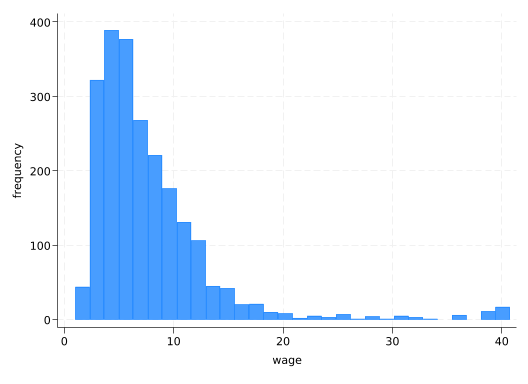

In [19]:
parqit histogram wage, bins(30)
display as text "Observations: " as result r(N) as text ", bins: " as result r(bins) ///
    as text ", bin width: " as result %5.3f r(width)
display as text "Stata's memory: " as result _N as text " observations"

## 9. New variables and subgroups

Statistics describe the *current plan*, so shape the view first and summarize after.
For example, log wages:

In [20]:
parqit gen double ln_wage = ln(wage)
parqit summarize wage ln_wage


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        wage |      2,246    7.766949    5.755523   1.004952   40.74659
     ln_wage |      2,246    1.868645      .57458   .0049396   3.707372


There is no `if` qualifier on the statistics. To describe a subgroup, open a **second,
named view** and filter it: the first view is not affected. `parqit views` lists the
open views and `parqit view` *name* switches between them.

In [21]:
parqit use using "$NB/nlsw88.parquet", name(graduates)
parqit keep if collgrad == 1
parqit summarize wage hours
parqit views

(lazy view graduates opened over /tmp/parqit_notebooks/nlsw88.parquet: 17 columns; schema probed, no
>  rows loaded — use parqit collect or parqit save)

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        wage |        532    10.52606    6.325833   1.032247   40.74659
       hours |        531    38.82674    11.69955          1         75

    view                  columns    steps   source
    ----------------------------------------------------------------------
    default                    18        1   /tmp/parqit_notebooks/nlsw88.parquet
  * graduates                  17        1   /tmp/parqit_notebooks/nlsw88.parquet
    (* = current)



In [22]:
parqit view default
parqit summarize wage hours

(current view: default)

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        wage |      2,246    7.766949    5.755523   1.004952   40.74659
       hours |      2,242    37.21811    10.50914          1         80


College graduates earn 10.53 dollars an hour on average, against 7.77 for all the women
in the sample.

## 10. Statistics as a dataset: `collapse`, `pivot`, `contract`

Sometimes you want the statistics as data, to list, graph or export them. `collapse`
computes them on disk, `collect` brings in the small table, and from there any Stata
command applies, for example a graph.

In [23]:
parqit use using "$NB/nlsw88.parquet"
parqit collapse (p25) p25=wage (p50) median=wage (p75) p75=wage (count) n=wage, by(occupation)
parqit keep if !missing(occupation)
parqit collect, clear
list, noobs abbreviate(10)

(lazy view default opened over /tmp/parqit_notebooks/nlsw88.parquet: 17 columns; schema probed, no r
> ows loaded — use parqit collect or parqit save)
(5 vars, 13 obs collected; view default remains open)

  +---------------------------------------------------------------+
  |             occupation        p25     median        p75     n |
  |---------------------------------------------------------------|
  | Professional/Technical   7.045088   9.677936   12.20612   317 |
  |         Managers/Admin   5.845101   9.488725   12.57246   264 |
  |                  Sales    4.62963   6.046698   8.148145   726 |
  |     Clerical/Unskilled   3.872784   5.128979    9.29146   102 |
  |              Craftsmen   4.227053   5.797099   9.500801    53 |
  |---------------------------------------------------------------|
  |             Operatives   3.526568   5.016723   6.843801   246 |
  |              Transport   2.415459   2.936641   3.831444    28 |
  |               Laborers    3.10789   4.0646

The graph leaves out the four occupations with fewer than 20 women (`n`), whose medians
rest on too few observations.

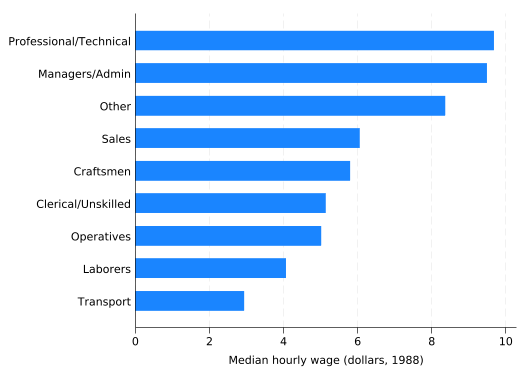

In [24]:
graph hbar median if n >= 20, over(occupation, sort(1) descending) ///
    ytitle("Median hourly wage (dollars, 1988)")

`pivot` is a spreadsheet pivot table in one verb: statistics by row groups, spread
across the values of a column variable. Here, the mean wage and the number of women by
industry, for non-union (`wage0`, `n0`) and union (`wage1`, `n1`) workers. Mining has no
union member in the sample, hence its dots.

In [25]:
parqit use using "$NB/nlsw88.parquet"
parqit keep if !missing(union, industry)
parqit pivot (mean) wage (count) n=wage, rows(industry) cols(union)
parqit collect, clear
format wage0 wage1 %6.2f
list, noobs abbreviate(10)

(lazy view default opened over /tmp/parqit_notebooks/nlsw88.parquet: 17 columns; schema probed, no r
> ows loaded — use parqit collect or parqit save)
(5 vars, 12 obs collected; view default remains open)

  +-----------------------------------------------------+
  |                industry   wage0    n0   wage1    n1 |
  |-----------------------------------------------------|
  |   Ag/Forestry/Fisheries    6.51    10    4.24     2 |
  |                  Mining    8.09     2       .     . |
  |            Construction    8.78    17    9.06     3 |
  |           Manufacturing    7.10   234    7.71    84 |
  |  Transport/Comm/Utility   10.98    39   11.40    48 |
  |-----------------------------------------------------|
  |  Wholesale/Retail trade    5.66   239    6.67    21 |
  | Finance/Ins/Real estate    8.92   144    7.34     9 |
  |     Business/Repair svc    7.36    51    6.07     8 |
  |       Personal services    4.21    58    3.82     5 |
  |   Entertainment/Rec svc    7.02    1

`contract` gives frequencies as a dataset, one row per combination with its count:

In [26]:
parqit use using "$NB/nlsw88.parquet"
parqit contract race collgrad, freq(women)
parqit collect, clear
list, noobs sepby(race)

(lazy view default opened over /tmp/parqit_notebooks/nlsw88.parquet: 17 columns; schema probed, no r
> ows loaded — use parqit collect or parqit save)
(3 vars, 6 obs collected; view default remains open)

  +----------------------------------+
  |  race           collgrad   women |
  |----------------------------------|
  | White   Not college grad    1217 |
  | White       College grad     420 |
  |----------------------------------|
  | Black   Not college grad     480 |
  | Black       College grad     103 |
  |----------------------------------|
  | Other   Not college grad      17 |
  | Other       College grad       9 |
  +----------------------------------+


## 11. A trap: missing values in comparisons

In Stata a missing value is larger than any number, so `hours > 40` is *true* when
`hours` is missing. By default parqit follows SQL instead: a comparison with a missing
value is *unknown*, so those rows are left out. `parqit set statamissing on` switches to
Stata's rule. The two counts below differ by the 4 women whose hours are missing:

In [27]:
parqit use using "$NB/nlsw88.parquet"
parqit count if hours > 40
parqit set statamissing on
parqit count if hours > 40
parqit set statamissing off

(lazy view default opened over /tmp/parqit_notebooks/nlsw88.parquet: 17 columns; schema probed, no r
> ows loaded — use parqit collect or parqit save)
                    390
                    394


Stating the intention explicitly, `hours > 40 & !missing(hours)`, gives the same answer
under both rules and is good practice anyway.

## 12. The same numbers as Stata

This file is small, so we can load it and run Stata's own `summarize` on the same data.
The numbers agree. What differs is where the work happens: the native command needs the
data in memory; the parqit command does not.

In [28]:
parqit use using "$NB/nlsw88.parquet"
parqit summarize wage hours tenure

(lazy view default opened over /tmp/parqit_notebooks/nlsw88.parquet: 17 columns; schema probed, no r
> ows loaded — use parqit collect or parqit save)

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        wage |      2,246    7.766949    5.755523   1.004952   40.74659
       hours |      2,242    37.21811    10.50914          1         80
      tenure |      2,231     5.97785    5.510331          0   25.91667


In [29]:
parqit use "$NB/nlsw88.parquet", clear
summarize wage hours tenure

(17 vars, 2246 obs read from /tmp/parqit_notebooks/nlsw88.parquet)

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        wage |      2,246    7.766949    5.755523   1.004952   40.74659
       hours |      2,242    37.21811    10.50914          1         80
      tenure |      2,231     5.97785    5.510331          0   25.91667


## 13. Summary

| You want... | Command (on the current view) |
|---|---|
| Variables, labels, types | `parqit describe`, `parqit codebook` |
| Missing values | `parqit misstable summarize`, `parqit misstable patterns` |
| Duplicates and distinct values | `parqit duplicates report`, `parqit distinct`, `parqit levelsof` |
| Summary statistics | `parqit summarize [, detail]` |
| Frequencies | `parqit tabulate a [b] [, missing row col]` |
| Tables of statistics | `parqit tabstat vars, statistics(...) [by(group)]` |
| Correlations | `parqit correlate`, `parqit pwcorr [, obs sig]` |
| Histogram | `parqit histogram var [, bins(#)]` |
| A subgroup | a named view: `parqit use using file, name(sub)` + `parqit keep if ...` |
| Statistics as data | `parqit collapse`, `parqit pivot`, `parqit contract` + `parqit collect` |
| Stata's missing-value rule | `parqit set statamissing on` |

Apart from `collect`, all of them leave the data in memory untouched and bring back only
their results. The full list is in `help parqit`.

In [30]:
parqit close _all

(views closed)
